# MC-HNN Automatic Fingerprint Recognition System
Implementasi berdasarkan paper _A Robust Automatic Fingerprint Recognition System Using Multi-Connection Hopfield Neural Network_ (Yadav et al., 2022).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/JST_Hopfield-Fingerprint/dataset_final.zip'
extract_path = '/content/dataset_final'

print(f"Mengekstrak {zip_path} ke {extract_path}...")
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Ekstraksi selesai!")

    # Cek apakah hasil ekstrak bersarang (dataset_final/dataset_final)
    if os.path.exists(os.path.join(extract_path, 'dataset_final')):
        print("Folder dataset bersarang ditemukan.")
except Exception as e:
    print(f"Error saat ekstrak: {e}")

Mengekstrak /content/drive/MyDrive/JST_Hopfield-Fingerprint/dataset_final.zip ke /content/dataset_final...
Ekstraksi selesai!
Folder dataset bersarang ditemukan.


[*] Menggunakan Dataset Path: /content/dataset_final/dataset_final

[>] Memulai Fase Enrolment (Multi-Template):
    - Melatih pola: db3_101_1.tif
    - Melatih pola: db3_101_2.tif
    - Melatih pola: db3_101_3.tif
[+] Model berhasil dilatih dan disimpan!



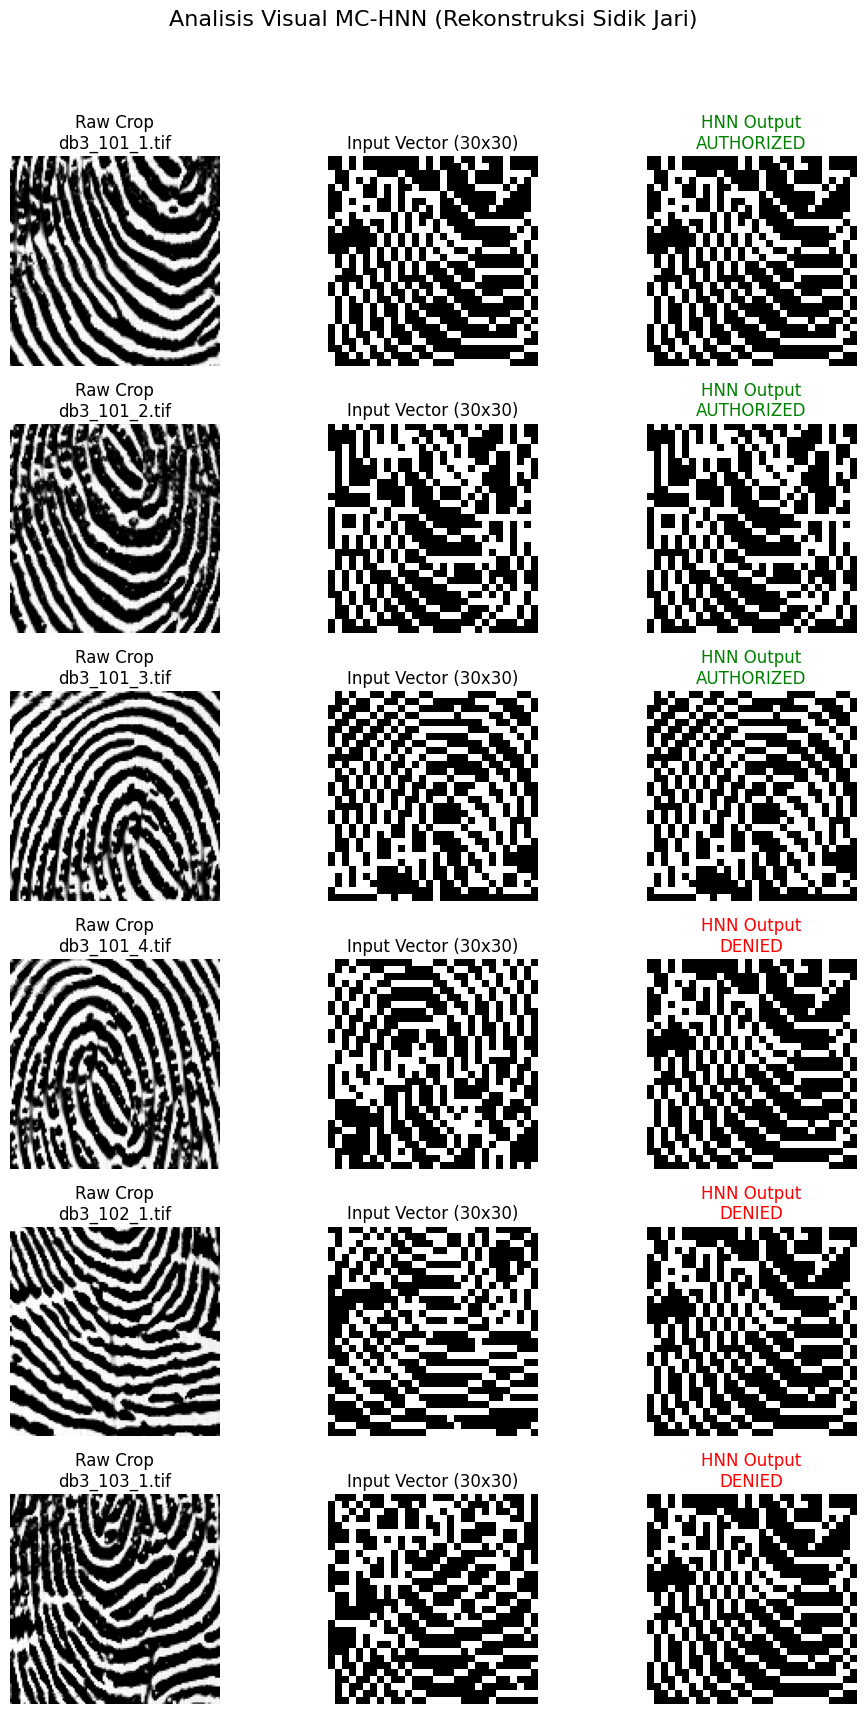


--- HASIL UJI COBA IDENTIFIKASI (MULTI-TEMPLATE) ---


,Sample Name,Initial Energy (SE),Result
0,db3_101_1.tif,-404550.0,AUTHORIZED (Match ID: 0)
1,db3_101_2.tif,-404550.0,AUTHORIZED (Match ID: 1)
2,db3_101_3.tif,-404550.0,AUTHORIZED (Match ID: 2)
3,db3_101_4.tif,-272.0,DENIED (Low Affinity)
4,db3_102_1.tif,-518.0,DENIED (Low Affinity)
5,db3_103_1.tif,-2142.0,DENIED (Low Affinity)


In [ ]:
import os
import cv2
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize
from IPython.display import display

# ==========================================
# 1. KONFIGURASI DATASET PATH
# ==========================================
DATASET_PATH = '/content/dataset_final/dataset_final'
if not os.path.exists(DATASET_PATH) or not os.path.isdir(DATASET_PATH):
    paths = ['/content/dataset_asli/dataset_final', 'dataset_final', 'a:/JST_UAS/dataset_final']
    for p in paths:
        if os.path.exists(p):
            DATASET_PATH = p
            break

# ==========================================
# 2. PREPROCESSING FINGERPRINT
# ==========================================
def preprocess_fingerprint(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'Image tidak ditemukan di: {image_path}')

    h, w = img.shape
    center_y, center_x = h // 2, w // 2
    half_crop = 60 # Crop 120x120

    y1, y2 = max(0, center_y - half_crop), min(h, center_y + half_crop)
    x1, x2 = max(0, center_x - half_crop), min(w, center_x + half_crop)
    cropped = img[y1:y2, x1:x2]

    # Resize ketat menjadi 30x30 sesuai paper
    resized = cv2.resize(cropped, (30, 30), interpolation=cv2.INTER_AREA)

    thresh = threshold_otsu(resized)
    ridge_binary = resized < thresh
    skeleton = skeletonize(ridge_binary)
    bipolar = np.where(skeleton, 1, -1)

    return bipolar.flatten(), cropped

# ==========================================
# 3. FASE ENROLMENT (TRAINING MULTI-TEMPLATE)
# ==========================================
def mchnn_enrolment(stored_patterns):
    P, n = stored_patterns.shape
    W = []
    E = np.zeros(P)

    for p in range(P):
        S = stored_patterns[p]
        W_p = np.outer(S, S)
        np.fill_diagonal(W_p, 0)
        W.append(W_p)
        E[p] = -0.5 * np.sum(np.outer(S, S) * W_p)

    return W, E

# ==========================================
# 4. FASE MATCHING & VISUALISASI
# ==========================================
def mchnn_matching(I_test, W, E, theta=0, max_iters=50):
    P = len(W)
    n = len(I_test)
    SE = np.zeros(P)

    for p in range(P):
        SE[p] = -0.5 * np.sum(np.outer(I_test, I_test) * W[p])

    min_SE = np.min(SE)
    candidate_indices = np.where(SE == min_SE)[0]
    final_candidates = []

    for p in candidate_indices:
        W_p = W[p]
        O = I_test.copy()
        converged = False
        iters = 0

        while not converged and iters < max_iters:
            O_prev = O.copy()
            random_order = np.random.permutation(n)

            for i in random_order:
                Onet_i = I_test[i] + np.dot(W_p[i, :], O)
                if Onet_i > theta: O[i] = 1
                elif Onet_i < theta: O[i] = -1
                else: O[i] = 0

            if np.array_equal(O, O_prev):
                converged = True
            iters += 1

        SE1_p = -0.5 * np.sum(np.outer(O, O) * W_p)

        if np.isclose(SE1_p, E[p]):
            final_candidates.append({'id': p, 'output': O, 'SE1': SE1_p, 'Initial_SE': SE[p]})

    if len(final_candidates) == 0:
        return 'Access Denied', None, None, None
    elif len(final_candidates) == 1:
        return final_candidates[0]['id'], final_candidates[0]['SE1'], final_candidates[0]['Initial_SE'], final_candidates[0]['output']
    else:
        min_hd = float('inf')
        best_cand = None
        for cand in final_candidates:
            hd = np.sum(I_test != cand['output'])
            if hd < min_hd:
                min_hd = hd
                best_cand = cand
        return best_cand['id'], best_cand['SE1'], best_cand['Initial_SE'], best_cand['output']

# ==========================================
# 5. EXECUTION PIPELINE
# ==========================================
print(f'[*] Menggunakan Dataset Path: {DATASET_PATH}\n')

# Kita daftarkan 3 variasi sidik jari sekaligus
enrol_files = ['db3_101_1.tif', 'db3_101_2.tif', 'db3_101_3.tif']
stored_patterns = []

print('[>] Memulai Fase Enrolment (Multi-Template):')
for f in enrol_files:
    path = os.path.join(DATASET_PATH, f)
    bipolar_pattern, _ = preprocess_fingerprint(path)
    stored_patterns.append(bipolar_pattern)
    print(f'    - Melatih pola: {f}')

W_trained, E_trained = mchnn_enrolment(np.array(stored_patterns))
with open('mchnn_model_final.pkl', 'wb') as f:
    pickle.dump({'W': W_trained, 'E': E_trained}, f)
print('[+] Model berhasil dilatih dan disimpan!\n')

test_files = enrol_files + ['db3_101_4.tif', 'db3_102_1.tif', 'db3_103_1.tif']
results_data = []

# Setup visualisasi matplotlib
fig, axes = plt.subplots(len(test_files), 3, figsize=(10, 3 * len(test_files)))
fig.suptitle("Analisis Visual MC-HNN (Rekonstruksi Sidik Jari)", fontsize=16)

# Toleransi 30% dari energi ideal pertama
ENERGY_TOLERANCE = E_trained[0] * 0.70

for idx, filename in enumerate(test_files):
    test_path = os.path.join(DATASET_PATH, filename)
    I_test, raw_crop = preprocess_fingerprint(test_path)

    matched_id, converged_energy, initial_energy, O_output = mchnn_matching(I_test, W_trained, E_trained)

    # Logika status
    if matched_id == 'Access Denied':
        status = 'DENIED (Not Stable)'
        display_output = I_test # Jika gagal konvergen, tampilkan input aslinya
    else:
        if initial_energy <= ENERGY_TOLERANCE:
            status = f'AUTHORIZED (Match ID: {matched_id})'
        else:
            status = 'DENIED (Low Affinity)'
        display_output = O_output

    results_data.append({
        'Sample Name': filename,
        'Initial Energy (SE)': initial_energy if initial_energy else 'N/A',
        'Result': status
    })

    # VISUALISASI
    ax_raw, ax_in, ax_out = axes[idx]

    ax_raw.imshow(raw_crop, cmap='gray')
    ax_raw.set_title(f"Raw Crop\n{filename}")
    ax_raw.axis('off')

    # Reshape ke 30x30 karena kita compress di preprocessing
    ax_in.imshow(I_test.reshape(30, 30) == 1, cmap='gray')
    ax_in.set_title("Input Vector (30x30)")
    ax_in.axis('off')

    color = 'green' if 'AUTHORIZED' in status else 'red'
    ax_out.imshow(display_output.reshape(30, 30) == 1, cmap='gray')
    ax_out.set_title(f"HNN Output\n{status.split(' (')[0]}", color=color)
    ax_out.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# PRESENTASI TABEL PANDAS
df_results = pd.DataFrame(results_data)
print('\n--- HASIL UJI COBA IDENTIFIKASI (MULTI-TEMPLATE) ---')
display(df_results)

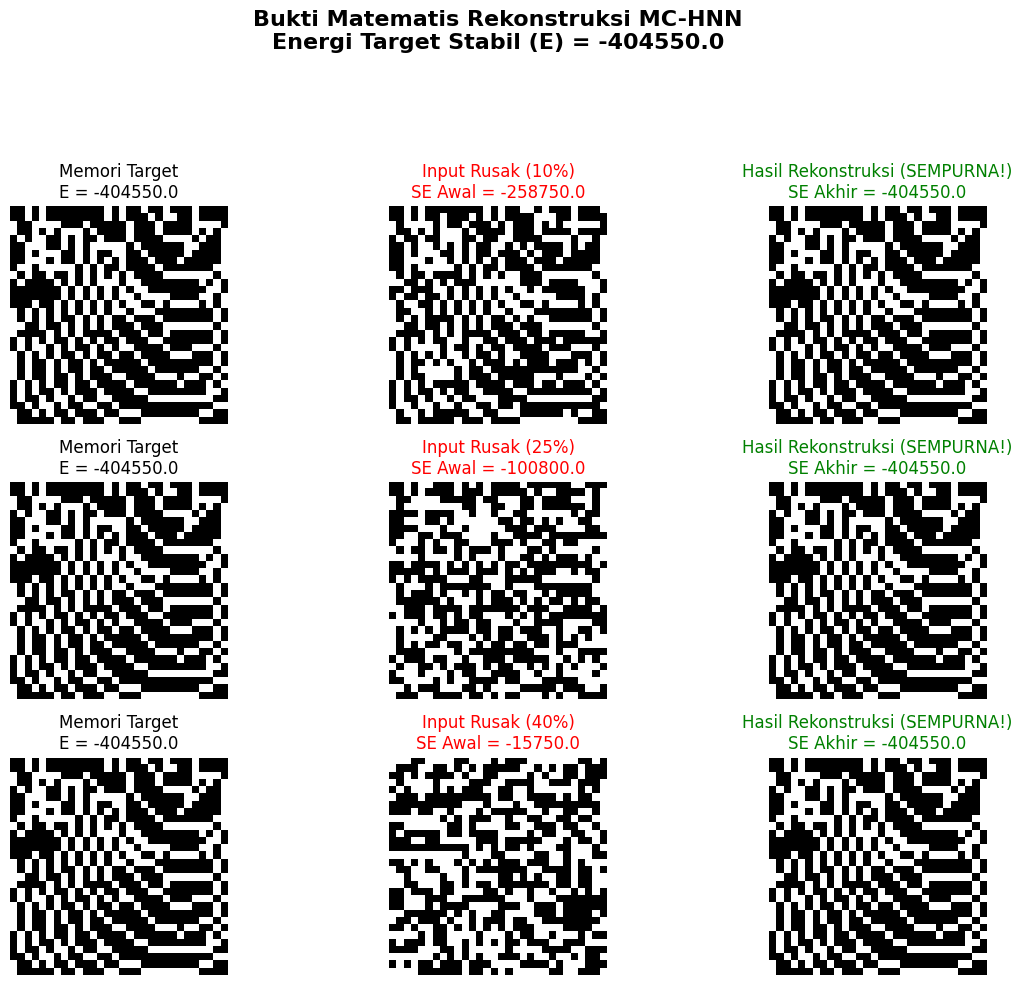

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize

# ==========================================
# 1. SETUP & PREPROCESSING
# ==========================================
DATASET_PATH = '/content/dataset_final/dataset_final'
if not os.path.exists(DATASET_PATH):
    paths = ['/content/dataset_asli/dataset_final', 'dataset_final', 'a:/JST_UAS/dataset_final']
    for p in paths:
        if os.path.exists(p): DATASET_PATH = p; break

def preprocess_fingerprint(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    center_y, center_x = h // 2, w // 2
    cropped = img[max(0, center_y-60):min(h, center_y+60), max(0, center_x-60):min(w, center_x+60)]
    resized = cv2.resize(cropped, (30, 30), interpolation=cv2.INTER_AREA)
    thresh = threshold_otsu(resized)
    skeleton = skeletonize(resized < thresh)
    return np.where(skeleton, 1, -1).flatten()

def add_noise(pattern, noise_ratio):
    noisy_pattern = pattern.copy()
    num_flips = int(len(pattern) * noise_ratio)
    flip_indices = np.random.choice(len(pattern), num_flips, replace=False)
    noisy_pattern[flip_indices] *= -1
    return noisy_pattern

# ==========================================
# 2. EKSEKUSI REKONSTRUKSI & ENERGI MC-HNN
# ==========================================
golden_path = os.path.join(DATASET_PATH, 'db3_101_1.tif')
S_golden = preprocess_fingerprint(golden_path)

# Bangun Etalon Array (W) & Hitung Energi Ideal (E)
W_p = np.outer(S_golden, S_golden)
np.fill_diagonal(W_p, 0)
E_ideal = -0.5 * np.sum(np.outer(S_golden, S_golden) * W_p)

noise_levels = [0.10, 0.25, 0.40]
results = []

for noise in noise_levels:
    I_noisy = add_noise(S_golden, noise)

    # Hitung Energi Awal Input yang Rusak (SE)
    SE_initial = -0.5 * np.sum(np.outer(I_noisy, I_noisy) * W_p)

    # Fase Rekonstruksi (Asynchronous Update)
    O_recon = I_noisy.copy()
    for _ in range(50):
        O_prev = O_recon.copy()
        random_order = np.random.permutation(len(I_noisy))
        for i in random_order:
            Onet_i = I_noisy[i] + np.dot(W_p[i, :], O_recon)
            O_recon[i] = 1 if Onet_i > 0 else (-1 if Onet_i < 0 else 0)
        if np.array_equal(O_recon, O_prev):
            break

    # Hitung Energi Akhir setelah Konvergen (SE1)
    SE1_converged = -0.5 * np.sum(np.outer(O_recon, O_recon) * W_p)

    results.append((I_noisy, O_recon, noise, SE_initial, SE1_converged))

# ==========================================
# 3. VISUALISASI BUKTI REKONSTRUKSI & ENERGI
# ==========================================
fig, axes = plt.subplots(len(noise_levels), 3, figsize=(12, 10))
fig.suptitle(f"Bukti Matematis Rekonstruksi MC-HNN\nEnergi Target Stabil (E) = {E_ideal}", fontsize=16, fontweight='bold')

for idx, (I_noisy, O_recon, noise, SE_initial, SE1_converged) in enumerate(results):
    ax_ori, ax_in, ax_out = axes[idx]

    # Kolom 1: Target Asli (Golden Memory)
    ax_ori.imshow(S_golden.reshape(30, 30) == 1, cmap='gray')
    ax_ori.set_title(f"Memori Target\nE = {E_ideal}")
    ax_ori.axis('off')

    # Kolom 2: Input yang Rusak
    ax_in.imshow(I_noisy.reshape(30, 30) == 1, cmap='gray')
    # Warna merah menunjukkan energi belum stabil / menjauhi target
    ax_in.set_title(f"Input Rusak ({int(noise*100)}%)\nSE Awal = {SE_initial}", color='red')
    ax_in.axis('off')

    # Kolom 3: Hasil Rekonstruksi HNN
    ax_out.imshow(O_recon.reshape(30, 30) == 1, cmap='gray')
    is_perfect = np.array_equal(O_recon, S_golden)
    title_color = 'green' if is_perfect else 'orange'
    status_text = "SEMPURNA!" if is_perfect else "Parsial"
    # Warna hijau menunjukkan energi berhasil turun dan stabil di angka ideal
    ax_out.set_title(f"Hasil Rekonstruksi ({status_text})\nSE Akhir = {SE1_converged}", color=title_color)
    ax_out.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()